# ***TinyML Lab-1: Real-Time Rotational Dynamics & Edge-AI Payload Safety System***
## ***Reg.No: 2548514***

Sensor data of Gyroscope -> Preprocessing -> Train Test Split -> Model -> Evaluation -> Quantization

Data Collection: Collect 2 csv files. one file has angles where the pen didn't fall. Other has angles where the pen fell. Label them as 'Pen fell' and 'Pen didn't fall' respectively. Combine these 2 csv files and use it to train the model.



### **1) Import libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


### **2) Read the CSV files**

In [2]:
no_fall = pd.read_csv("No Fall.csv")
fall = pd.read_csv("Fall.csv")
test_data = pd.read_csv("Test.csv")

print("No Fall shape:", no_fall.shape)
print("Fall shape:", fall.shape)
print("Test shape:", test_data.shape)

No Fall shape: (31193, 5)
Fall shape: (3853, 5)
Test shape: (12840, 5)


### **3) Inspect columns**

In [3]:
print("No Fall columns:")
print(no_fall.columns.tolist())

print("\nFall columns:")
print(fall.columns.tolist())

print("\nTest columns:")
print(test_data.columns.tolist())

No Fall columns:
['Time (s)', 'Gyroscope x (rad/s)', 'Gyroscope y (rad/s)', 'Gyroscope z (rad/s)', 'Absolute (rad/s)']

Fall columns:
['Time (s)', 'Gyroscope x (rad/s)', 'Gyroscope y (rad/s)', 'Gyroscope z (rad/s)', 'Absolute (rad/s)']

Test columns:
['Time (s)', 'Gyroscope x (rad/s)', 'Gyroscope y (rad/s)', 'Gyroscope z (rad/s)', 'Absolute (rad/s)']


### **4) Rename the columns**

In [4]:
rename_dict = {
    'Time (s)': 'time',
    'Gyroscope x (rad/s)': 'gyro_x',
    'Gyroscope y (rad/s)': 'gyro_y',
    'Gyroscope z (rad/s)': 'gyro_z',
    'Absolute (rad/s)': 'gyro_absolute'
}

no_fall = no_fall.rename(columns=rename_dict)
fall = fall.rename(columns=rename_dict)
test_data = test_data.rename(columns=rename_dict)

print(no_fall.columns.tolist())

['time', 'gyro_x', 'gyro_y', 'gyro_z', 'gyro_absolute']


### **5) Add target labels**

In [5]:
no_fall['target'] = 0
fall['target'] = 1

print(no_fall.head())
print(fall.head())

       time    gyro_x    gyro_y    gyro_z  gyro_absolute  target
0  0.018764  0.044208 -0.168711  0.033955       0.177682       0
1  0.020757  0.048469 -0.153797  0.043543       0.167030       0
2  0.022750  0.053796 -0.134623  0.055261       0.155148       0
3  0.024743  0.055926 -0.116513  0.068044       0.146058       0
4  0.026736  0.060187 -0.098404  0.079762       0.140242       0
       time    gyro_x    gyro_y    gyro_z  gyro_absolute  target
0  0.103617 -0.097488  0.037262  0.102575       0.146335       1
1  0.108586 -0.096387  0.038362  0.102575       0.145890       1
2  0.113556 -0.096387  0.044825  0.100375       0.146202       1
3  0.118525 -0.095288  0.045787  0.100375       0.145778       1
4  0.123495 -0.091025  0.049087  0.099413       0.143450       1


### **6) Verify the labels**

In [6]:
print("No Fall labels:")
print(no_fall['target'].value_counts())

print("\nFall labels:")
print(fall['target'].value_counts())

No Fall labels:
target
0    31193
Name: count, dtype: int64

Fall labels:
target
1    3853
Name: count, dtype: int64


### **7) Combine the two datasets**

In [7]:
df = pd.concat(
    [no_fall, fall],
    ignore_index=True
)

print("Combined shape:", df.shape)

Combined shape: (35046, 6)


### **8) Check missing values**

In [8]:
print(df.isnull().sum())

time             0
gyro_x           0
gyro_y           0
gyro_z           0
gyro_absolute    0
target           0
dtype: int64


### **9) Check data types**

In [9]:
print(df.dtypes)

time             float64
gyro_x           float64
gyro_y           float64
gyro_z           float64
gyro_absolute    float64
target             int64
dtype: object


### **10) Verify Absolute**

In [10]:
df['absolute_calculated'] = np.sqrt(
    df['gyro_x']**2 +
    df['gyro_y']**2 +
    df['gyro_z']**2
)

df['absolute_difference'] = (
    df['gyro_absolute'] -
    df['absolute_calculated']
).abs()

print(df['absolute_difference'].describe())

count    3.504600e+04
mean     3.889533e-11
std      8.953462e-11
min      6.938894e-18
25%      3.657921e-12
50%      1.384126e-11
75%      4.071407e-11
max      9.465495e-10
Name: absolute_difference, dtype: float64


### **11) Visualize Absolute Difference**

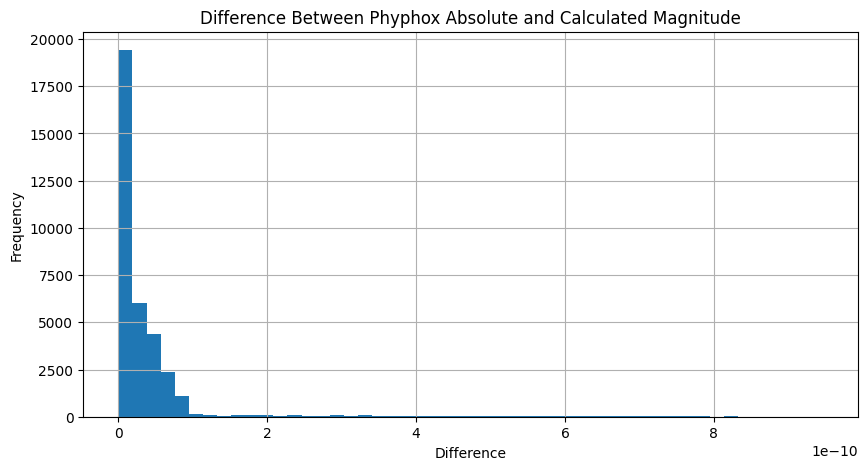

In [11]:
plt.figure(figsize=(10, 5))

plt.hist(
    df['absolute_difference'],
    bins=50
)

plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.title('Difference Between Phyphox Absolute and Calculated Magnitude')
plt.grid(True)

plt.show()

### **12) Remove verification columns**

In [12]:
df = df.drop(
    columns=[
        'absolute_calculated',
        'absolute_difference'
    ]
)

print(df.columns)

Index(['time', 'gyro_x', 'gyro_y', 'gyro_z', 'gyro_absolute', 'target'], dtype='object')


### **13) Class distribution**

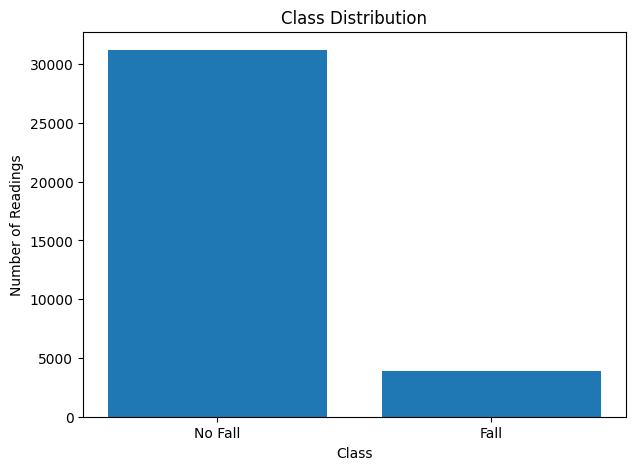

target
0    31193
1     3853
Name: count, dtype: int64


In [13]:
class_counts = df['target'].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ['No Fall', 'Fall'],
    class_counts.values
)

plt.xlabel('Class')
plt.ylabel('Number of Readings')
plt.title('Class Distribution')

plt.show()

print(class_counts)

### **14) Visualise No-Fall and Fall Gyroscope Signals**

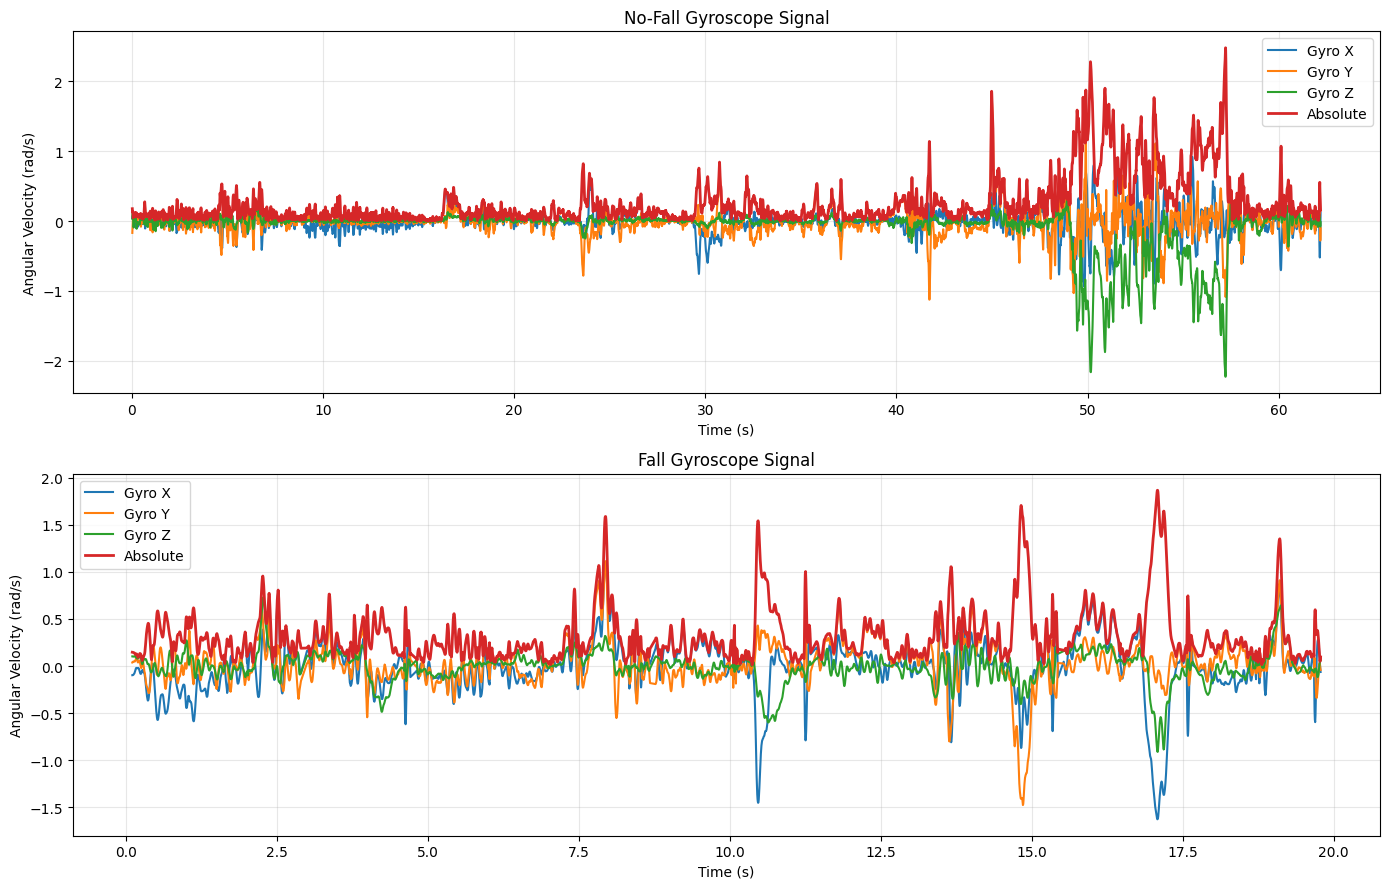

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

# No-Fall Gyroscope Signal
axes[0].plot(no_fall['time'], no_fall['gyro_x'], label='Gyro X')
axes[0].plot(no_fall['time'], no_fall['gyro_y'], label='Gyro Y')
axes[0].plot(no_fall['time'], no_fall['gyro_z'], label='Gyro Z')
axes[0].plot(no_fall['time'], no_fall['gyro_absolute'],
             label='Absolute', linewidth=2)

axes[0].set_title('No-Fall Gyroscope Signal')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Angular Velocity (rad/s)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Fall Gyroscope Signal
axes[1].plot(fall['time'], fall['gyro_x'], label='Gyro X')
axes[1].plot(fall['time'], fall['gyro_y'], label='Gyro Y')
axes[1].plot(fall['time'], fall['gyro_z'], label='Gyro Z')
axes[1].plot(fall['time'], fall['gyro_absolute'],
             label='Absolute', linewidth=2)

axes[1].set_title('Fall Gyroscope Signal')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Angular Velocity (rad/s)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **15) Window creation function**

In [15]:
WINDOW_SIZE = 50
STEP_SIZE = 25

def create_windows(data, window_size=50, step_size=25):

    X = []
    y = []

    values = data[features].values

    # All rows in this dataframe have the same class
    label = data['target'].iloc[0]

    for start in range(
        0,
        len(values) - window_size + 1,
        step_size
    ):

        window = values[
            start:start + window_size
        ]

        X.append(window)
        y.append(label)

    return np.array(X), np.array(y)

### **16) Create No-Fall windows**

In [17]:
features = ['gyro_x', 'gyro_y', 'gyro_z', 'gyro_absolute']

X_no_fall, y_no_fall = create_windows(
    no_fall,
    WINDOW_SIZE,
    STEP_SIZE
)

print("No-Fall X shape:", X_no_fall.shape)
print("No-Fall y shape:", y_no_fall.shape)

No-Fall X shape: (1246, 50, 4)
No-Fall y shape: (1246,)


### **17) Create Fall windows**

In [18]:
X_fall, y_fall = create_windows(
    fall,
    WINDOW_SIZE,
    STEP_SIZE
)

print("Fall X shape:", X_fall.shape)
print("Fall y shape:", y_fall.shape)

Fall X shape: (153, 50, 4)
Fall y shape: (153,)


### **18) Combine windows**

In [19]:
X = np.concatenate(
    [X_no_fall, X_fall],
    axis=0
)

y = np.concatenate(
    [y_no_fall, y_fall],
    axis=0
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1399, 50, 4)
y shape: (1399,)


### **19) Train/Test split**

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (1119, 50, 4)
Testing : (280, 50, 4)


### **20) Validation split**

In [21]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training  :", X_train.shape)
print("Validation:", X_val.shape)
print("Testing   :", X_test.shape)

Training  : (895, 50, 4)
Validation: (224, 50, 4)
Testing   : (280, 50, 4)


### **21) Normalize the features (Standard Scaler)**

In [22]:
scaler = StandardScaler()

X_train_2d = X_train.reshape(
    -1,
    X_train.shape[-1]
)

scaler.fit(X_train_2d)

StandardScaler()

In [23]:
X_train = scaler.transform(
    X_train.reshape(-1, X_train.shape[-1])
).reshape(X_train.shape)

X_val = scaler.transform(
    X_val.reshape(-1, X_val.shape[-1])
).reshape(X_val.shape)

X_test = scaler.transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test.shape)

### **22) Calculate class weights**

In [24]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(
    zip(classes, weights)
)

print(class_weights)

{np.int64(0): np.float64(0.5614805520702635), np.int64(1): np.float64(4.566326530612245)}


### **23) Build the 1D CNN**

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    GlobalAveragePooling1D,
    Dense,
    Dropout)
model = Sequential([
    Input(
        shape=(
            WINDOW_SIZE,
            len(features))),
    Conv1D(
        filters=32,
        kernel_size=3,
        activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'),
    GlobalAveragePooling1D(),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 48, 32)         │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 22, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,737 (34.13 KB)

 Trainable params: 8,737 (34.13 KB)

 Non-trainable params: 0 (0.00 B)

### **24) Compile**

In [27]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy'
    ]
)

### **25) Train**

In [28]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_val,
        y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    verbose=1)

Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.2916 - loss: 0.6594 - val_accuracy: 0.5670 - val_loss: 0.7287
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6291 - loss: 0.6241 - val_accuracy: 0.6384 - val_loss: 0.7151
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7330 - loss: 0.5820 - val_accuracy: 0.6518 - val_loss: 0.6982
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7520 - loss: 0.5572 - val_accuracy: 0.6741 - val_loss: 0.6708
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7285 - loss: 0.5255 - val_accuracy: 0.7143 - val_loss: 0.6116
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7620 - loss: 0.5175 - val_accuracy: 0.7143 - val_loss: 0.6068
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7285 - loss: 0.5014 - val_accuracy: 0.7411 - val_loss: 0.5125
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7531 - loss: 0.4799 - val_accuracy: 0.7455 - val_lo

### **26) Plot training accuracy**

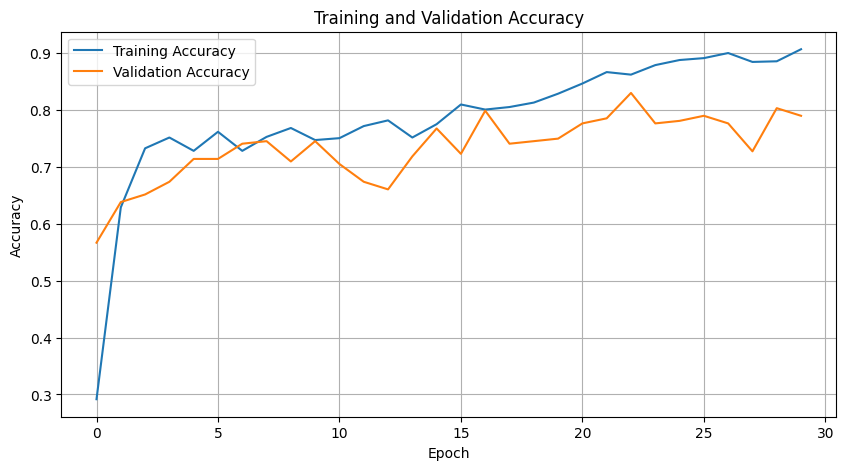

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy')
plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()

### **27) Plot loss**

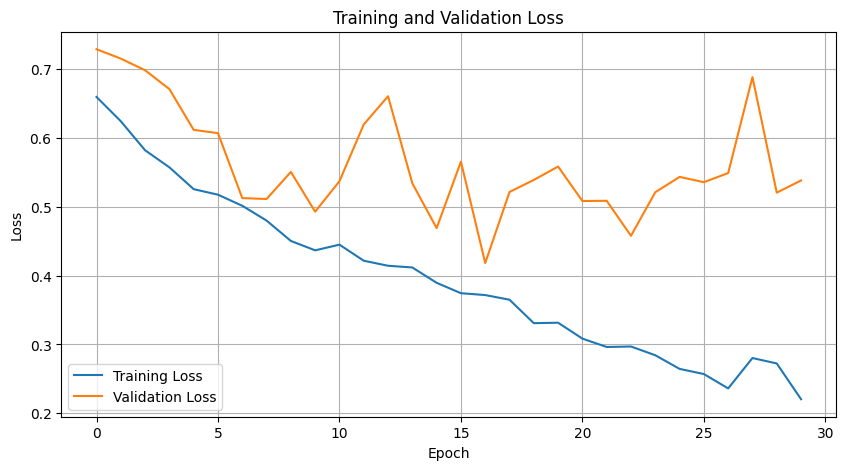

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(
    history.history['loss'],
    label='Training Loss')
plt.plot(
    history.history['val_loss'],
    label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

### **28) Evaluate test set**

In [31]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.3361372947692871
Test Accuracy: 0.8785714507102966


### **29) Generate predictions**

In [32]:
y_probability = model.predict(
    X_test
).flatten()

y_pred = (
    y_probability >= 0.5
).astype(int)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


### **30) Classification report**

In [33]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            'No Fall',
            'Fall'
        ]))

              precision    recall  f1-score   support

     No Fall       0.97      0.89      0.93       249
        Fall       0.47      0.81      0.60        31

    accuracy                           0.88       280
   macro avg       0.72      0.85      0.76       280
weighted avg       0.92      0.88      0.89       280



### **31) Confusion matrix**

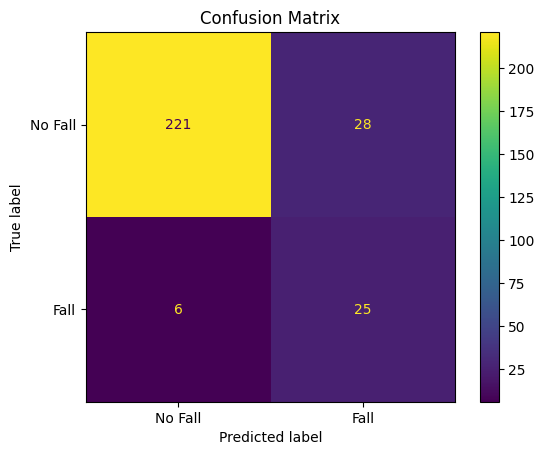

In [34]:
cm = confusion_matrix(
    y_test,
    y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        'No Fall',
        'Fall'
    ])

disp.plot()
plt.title('Confusion Matrix')

plt.show()

### **32) Calculate metrics explicitly**

In [35]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8786
Precision: 0.4717
Recall   : 0.8065
F1 Score : 0.5952


### **33) Save the Keras model**

In [36]:
model.save('pen_fall_classifier.keras')
print("Keras model saved.")

Keras model saved.


### **34) Convert to TensorFlow Lite**

In [37]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open(
    'pen_fall_classifier.tflite',
    'wb') as f:
    f.write(tflite_model)
print("TFLite model successfully created.")

Saved artifact at '/tmp/tmpb15tgqhh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 4), dtype=tf.float32, name='keras_tensor_8')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139375238229712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139375238227600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139375238228944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139375238227216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139375238227408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139375238226832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139375238227024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139375238225296: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model successfully created.


### **35) Check TFLite model size**

In [38]:
import os

size_kb = (
    os.path.getsize(
        'pen_fall_classifier.tflite') / 1024)
print(f"TFLite model size: {size_kb:.2f} KB")

TFLite model size: 38.82 KB


### **36) Check Test.csv**

In [39]:
print(test_data.head())

print("\nColumns:")
print(test_data.columns.tolist())

print("\nShape:")
print(test_data.shape)

       time    gyro_x    gyro_y    gyro_z  gyro_absolute
0  0.017502  0.153931  0.197740  0.037151       0.253329
1  0.019495  0.151800  0.204131  0.036086       0.256934
2  0.021488  0.143278  0.207327  0.032890       0.254155
3  0.023481  0.134756  0.210523  0.027564       0.251473
4  0.025474  0.125168  0.210523  0.023303       0.246028

Columns:
['time', 'gyro_x', 'gyro_y', 'gyro_z', 'gyro_absolute']

Shape:
(12840, 5)


### **37) Create Test windows**

In [40]:
def create_test_windows(
    data,
    window_size=50,
    step_size=25):
    X = []
    values = data[features].values
    for start in range(0,
        len(values) - window_size + 1,
        step_size):
        window = values[
            start:start + window_size]
        X.append(window)
    return np.array(X)

In [41]:
X_test_real = create_test_windows(
    test_data,
    WINDOW_SIZE,
    STEP_SIZE)
print("Test windows:",X_test_real.shape)

Test windows: (512, 50, 4)


### **38) Normalize Test.csv**

In [42]:
X_test_real = scaler.transform(
    X_test_real.reshape(
        -1,
        X_test_real.shape[-1])
).reshape(X_test_real.shape)

print(X_test_real.shape)

(512, 50, 4)


### **39) Load TFLite model**

In [43]:
interpreter = tf.lite.Interpreter(model_path='pen_fall_classifier.tflite')
interpreter.allocate_tensors()
input_details = (interpreter.get_input_details())
output_details = (interpreter.get_output_details())

print("Input:")
print(input_details)

print("\nOutput:")
print(output_details)

Input:
[{'name': 'serving_default_keras_tensor_8:0', 'index': 0, 'shape': array([ 1, 50,  4], dtype=int32), 'shape_signature': array([-1, 50,  4], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]

Output:
[{'name': 'StatefulPartitionedCall_1:0', 'index': 26, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


### **40) Predict Test.csv using TFLite**

In [44]:
predictions = []
for sample in X_test_real:
    sample = sample.astype(np.float32)
    sample = np.expand_dims(sample, axis=0)
    interpreter.set_tensor(
        input_details[0]['index'],
        sample)
    interpreter.invoke()
    output = interpreter.get_tensor(
        output_details[0]['index'])
    probability = output[0][0]
    predictions.append(probability)

predictions = np.array(predictions)

### **41) Convert probabilities to labels**

In [45]:
predicted_labels = (
    predictions >= 0.5
).astype(int)

In [46]:
predicted_class = np.where(
    predicted_labels == 1,
    'Fall',
    'No Fall'
)

### **42) Create final prediction table**

In [47]:
results = pd.DataFrame({
    'window_number': np.arange(
        len(predictions)),
    'fall_probability': predictions,
    'prediction': predicted_class})

results.head(20)

,window_number,fall_probability,prediction
0,0,0.439559,No Fall
1,1,0.247376,No Fall
2,2,0.086393,No Fall
3,3,0.047770,No Fall
4,4,0.034931,No Fall
5,5,0.016223,No Fall
6,6,0.017596,No Fall
7,7,0.027506,No Fall
8,8,0.062130,No Fall
9,9,0.207544,No Fall


### **43) Visualize Test Predictions**

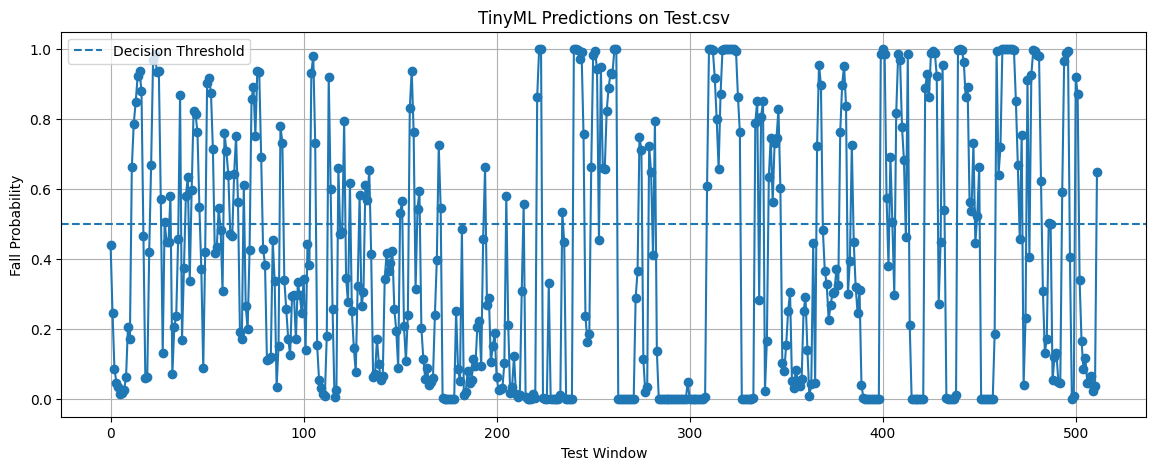

In [48]:
plt.figure(figsize=(14, 5))

plt.plot(
    results['fall_probability'],
    marker='o')
plt.axhline(
    0.5,
    linestyle='--',
    label='Decision Threshold')
plt.xlabel('Test Window')
plt.ylabel('Fall Probability')
plt.title('TinyML Predictions on Test.csv')
plt.legend()
plt.grid(True)

plt.show()

### **44) Count predicted classes**

In [49]:
print(results['prediction'].value_counts())

prediction
No Fall    321
Fall       191
Name: count, dtype: int64


### **45) Save predictions**

In [50]:
results.to_csv(
    'Test_predictions.csv',
    index=False)

print("Predictions saved to Test_predictions.csv")

Predictions saved to Test_predictions.csv


### **46) Download the TinyML model**

In [51]:
from google.colab import files

files.download('pen_fall_classifier.tflite')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

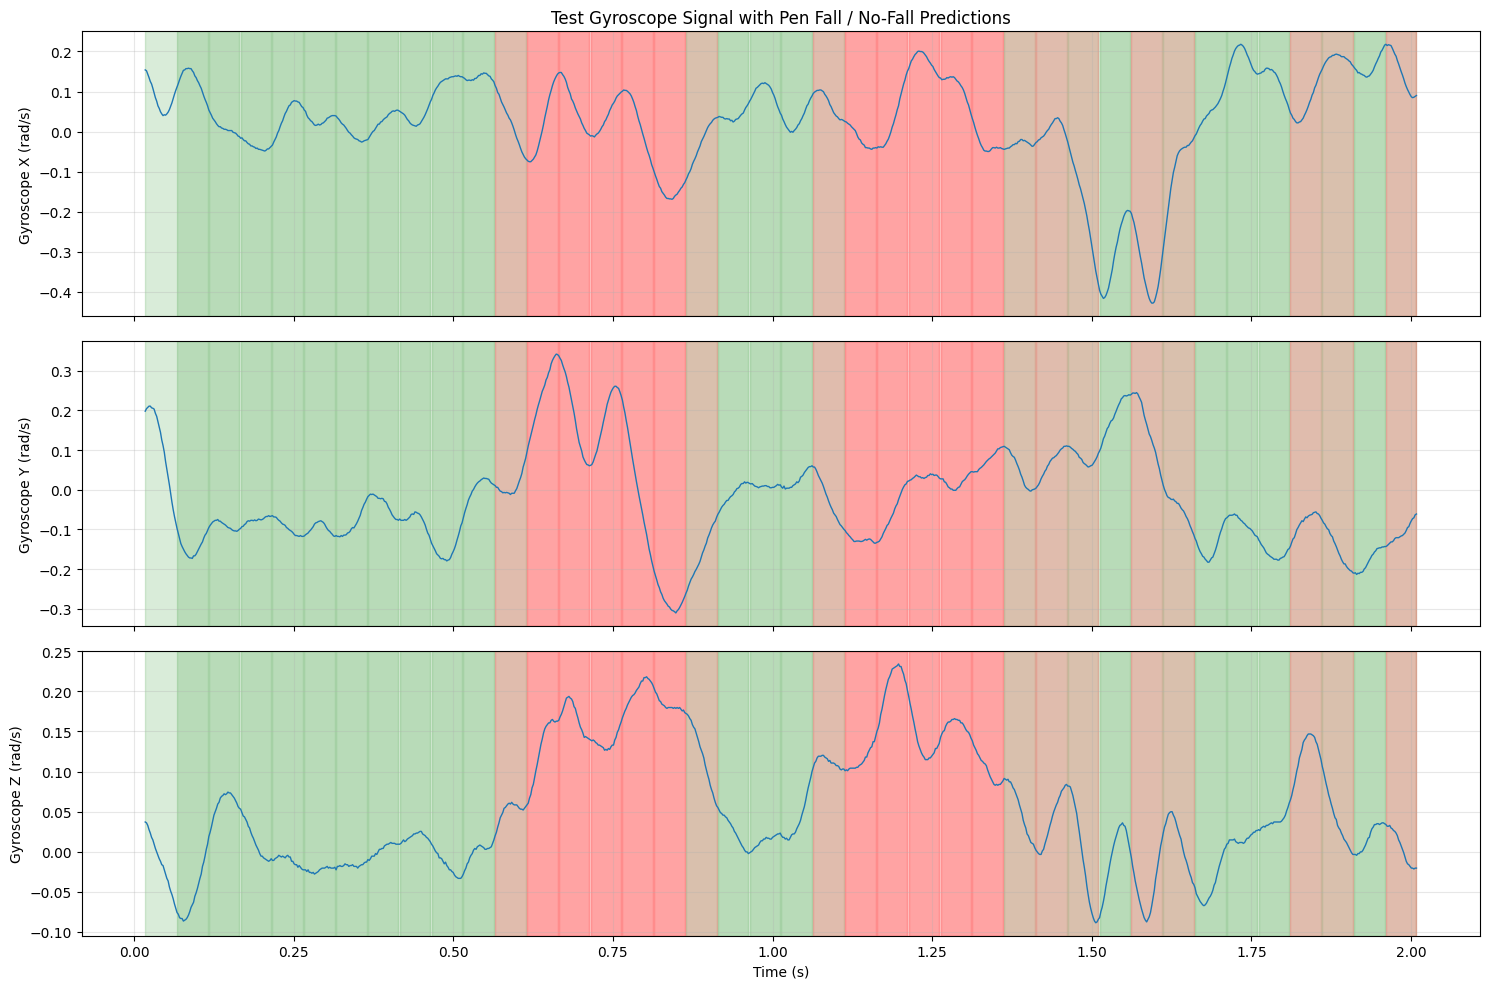

In [53]:
sample = test_data.copy()

# Select only the first sample/recording
# Change these values if you want another portion
start_row = 0
end_row = min(1000, len(sample))
sample = sample.iloc[start_row:end_row].copy()

# Plot X, Y and Z gyroscope signals
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

signals = [
    ('gyro_x', 'Gyroscope X (rad/s)'),
    ('gyro_y', 'Gyroscope Y (rad/s)'),
    ('gyro_z', 'Gyroscope Z (rad/s)')]

for ax, (column, ylabel) in zip(axes, signals):
    ax.plot(
        sample['time'],
        sample[column],
        linewidth=1,
        label=column)
    # Shade each prediction window
    for i, result in results.iterrows():
        # Window start and end row
        window_start = i * STEP_SIZE
        window_end = window_start + WINDOW_SIZE
        # Ignore windows outside selected sample
        if window_start >= len(sample):
            continue
        window_end = min(window_end, len(sample))
        # Time limits of this window
        t1 = sample['time'].iloc[window_start]
        t2 = sample['time'].iloc[window_end - 1]
        # Prediction
        prediction = result['prediction']
        # Fall = 1 → red
        # No Fall = 0 → green
        if prediction == 'Fall':
            ax.axvspan(
                t1,
                t2,
                color='red',
                alpha=0.20)
        else:
            ax.axvspan(
                t1,
                t2,
                color='green',
                alpha=0.15)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
# Labels
axes[0].set_title('Test Gyroscope Signal with Pen Fall / No-Fall Predictions')
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()